# 📊 Notebook 1 — Multi-Asset Data Generation for Derivative Hedging

**Project:** Derivative Hedging using RL + DL  
**Repo:** `Aryan-Lokhande-17/Derivative-Hedging-using-RL-DL`

## What this notebook does
1. Downloads real price data for **6 equities, oil, gold, FX** via `yfinance` (2020–2025)
2. Engineers **derivative-relevant features** (realized vol, log-returns, moneyness, Greeks proxy)
3. Synthesizes **options chains** (calls + puts) on each asset using Black-Scholes
4. Saves everything to the correct project directory structure
5. Validates data quality — no leakage, no NaN poisoning

## Directory structure produced
```
Derivative-Hedging-using-RL-DL/
├── data/
│   ├── raw/
│   │   ├── equities_raw.csv          ← raw OHLCV, all symbols
│   │   ├── oil_raw.csv               ← Brent crude
│   │   ├── gold_raw.csv              ← XAU/USD
│   │   └── fx_raw.csv                ← GBPUSD, EURUSD
│   ├── processed/
│   │   ├── all_assets_features.csv   ← unified feature matrix
│   │   ├── options_chains.csv        ← synthetic options on all assets
│   │   └── train_val_split.csv       ← time-split metadata
│   └── interim/
│       └── per_asset/                ← one CSV per ticker
```

---
**⚠️ Paper trading only — all data is historical/simulated, no live orders are placed.**

## 0. Setup — Install & Imports

In [1]:
# ── Install dependencies (Colab-safe) ──────────────────────────────────────
import subprocess, sys

pkgs = ["yfinance", "pandas", "numpy", "scipy", "matplotlib",
        "seaborn", "scikit-learn", "tqdm"]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("✅ All packages installed")

✅ All packages installed


In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"yfinance: {yf.__version__}")

Pandas  : 3.0.1
NumPy   : 2.4.2
yfinance: 1.2.0


## 1. Configuration — Tickers, Dates, Paths

In [3]:
# ── Project root — adjust if running locally ───────────────────────────────
# If on Colab: clone your repo first, then set ROOT accordingly
# !git clone https://github.com/Aryan-Lokhande-17/Derivative-Hedging-using-RL-DL.git

import os
ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")

# Fallback for local runs
if not os.path.exists(ROOT):
    ROOT = os.path.abspath(".")  # run from repo root locally

PATHS = {
    "raw":       os.path.join(ROOT, "data", "raw"),
    "processed": os.path.join(ROOT, "data", "processed"),
    "interim":   os.path.join(ROOT, "data", "interim", "per_asset"),
    "results":   os.path.join(ROOT, "results"),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("📁 Directory structure created:")
for k, v in PATHS.items():
    print(f"  {k:12s} → {v}")

# ── Date range ─────────────────────────────────────────────────────────────
START_DATE = "2020-01-01"
END_DATE   = "2025-03-31"   # up to Q1 2025

# ── Asset universe ─────────────────────────────────────────────────────────
ASSET_CONFIG = {
    # Equities — LSE (.L suffix) + global
    "equities": {
        "BP.L":   "BP plc (Oil & Gas, LSE)",
        "SHEL.L": "Shell plc (Oil & Gas, LSE)",
        "HSBA.L": "HSBC Holdings (Banking, LSE)",
        "LLOY.L": "Lloyds Banking Group (LSE)",
        "AZN.L":  "AstraZeneca (Pharma, LSE)",
        "RIO.L":  "Rio Tinto (Mining, LSE)",
    },
    # Commodities
    "oil": {
        "BZ=F":   "Brent Crude Futures",
        "CL=F":   "WTI Crude Futures",
    },
    # Precious metals
    "gold": {
        "GC=F":   "Gold Futures (XAU)",
        "SI=F":   "Silver Futures (XAG)",
    },
    # FX
    "fx": {
        "GBPUSD=X": "GBP/USD",
        "EURUSD=X": "EUR/USD",
    },
}

ALL_TICKERS = {}
for asset_class, symbols in ASSET_CONFIG.items():
    for sym, name in symbols.items():
        ALL_TICKERS[sym] = {"class": asset_class, "name": name}

print(f"\n📌 Total instruments: {len(ALL_TICKERS)}")
for sym, meta in ALL_TICKERS.items():
    print(f"  {sym:12s} | {meta['class']:10s} | {meta['name']}")

📁 Directory structure created:
  raw          → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\raw
  processed    → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\processed
  interim      → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\interim\per_asset
  results      → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results

📌 Total instruments: 12
  BP.L         | equities   | BP plc (Oil & Gas, LSE)
  SHEL.L       | equities   | Shell plc (Oil & Gas, LSE)
  HSBA.L       | equities   | HSBC Holdings (Banking, LSE)
  LLOY.L       | equities   | Lloyds Banking Group (LSE)
  AZN.L        | equities   | AstraZeneca (Pharma, LSE)
  RIO.L        | equities   | Rio Tinto (Mining, LSE)
  BZ=F         | oil        | Brent Crude Futures
  CL=F         | oil        | WTI Crude Futures
  GC=F         | gold       | Gold Futures (XAU)
  SI=F         | gold       | Silver Futures (XAG)
  GBPUSD=X     | fx         | GBP/USD
  EURUSD=X     | fx 

## 2. Download Historical OHLCV Data

In [4]:
def download_asset_class(tickers: dict, class_name: str, start: str, end: str) -> pd.DataFrame:
    """Download daily OHLCV for a group of tickers, return unified DataFrame."""
    dfs = []
    for sym in tqdm(tickers, desc=f"Downloading {class_name}"):
        try:
            raw = yf.download(sym, start=start, end=end, auto_adjust=True, progress=False)
            if raw.empty:
                print(f"  ⚠️  {sym}: empty — skipping")
                continue
            # Flatten multi-index if present
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
            raw.index = pd.to_datetime(raw.index)
            raw.index.name = "date"
            raw["symbol"]      = sym
            raw["asset_class"] = class_name
            raw["asset_name"]  = ALL_TICKERS[sym]["name"]
            raw.columns = [c.lower() for c in raw.columns]
            dfs.append(raw.reset_index())
        except Exception as e:
            print(f"  ❌ {sym}: {e}")

    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


# ── Download by asset class ────────────────────────────────────────────────
raw_frames = {}
for cls, syms in ASSET_CONFIG.items():
    df = download_asset_class(syms, cls, START_DATE, END_DATE)
    raw_frames[cls] = df
    out = os.path.join(PATHS["raw"], f"{cls}_raw.csv")
    df.to_csv(out, index=False)
    print(f"  💾 Saved {cls} → {out}  ({len(df):,} rows, {df['symbol'].nunique()} symbols)")

# ── Unified raw dataset ────────────────────────────────────────────────────
all_raw = pd.concat(raw_frames.values(), ignore_index=True)
all_raw.to_csv(os.path.join(PATHS["raw"], "all_assets_raw.csv"), index=False)

print(f"\n✅ Total raw rows : {len(all_raw):,}")
print(f"   Symbols        : {all_raw['symbol'].nunique()}")
print(f"   Date range     : {all_raw['date'].min()} → {all_raw['date'].max()}")
all_raw.groupby(["asset_class", "symbol"])["close"].describe()[["count", "mean", "min", "max"]]

  💾 Saved equities → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\raw\equities_raw.csv  (7,943 rows, 6 symbols)


  💾 Saved oil → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\raw\oil_raw.csv  (2,637 rows, 2 symbols)


  💾 Saved gold → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\raw\gold_raw.csv  (2,636 rows, 2 symbols)


  💾 Saved fx → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\raw\fx_raw.csv  (2,734 rows, 2 symbols)

✅ Total raw rows : 15,950
   Symbols        : 12
   Date range     : 2020-01-01 00:00:00 → 2025-03-28 00:00:00


count      mean       min        max
asset_class symbol                                           
equities    AZN.L    1324.0000 9810.7868 6212.7871 13271.8115
            BP.L     1323.0000  398.6785  192.8997   566.7023
            HSBA.L   1324.0000  537.3388  282.4099   941.6696
            LLOY.L   1324.0000   45.9011   23.9254    73.9643
            RIO.L    1324.0000 5130.8902 2954.3425  6631.9287
            SHEL.L   1324.0000 2053.5718  898.0643  2943.6760
fx          EURUSD=X 1367.0000    1.1060    0.9596     1.2341
            GBPUSD=X 1367.0000    1.2828    1.0728     1.4227
gold        GC=F     1318.0000 1982.7261 1477.3000  3086.5000
            SI=F     1318.0000   24.2297   11.7350    34.8970
oil         BZ=F     1319.0000   74.9508   19.3300   127.9800
            CL=F     1318.0000   70.9936  -37.6300   123.7000

## 3. Feature Engineering — Derivative-Relevant Features

In [5]:
# ── Black-Scholes Greeks helpers ──────────────────────────────────────────
def bs_d1_d2(S, K, T, r, sigma):
    """Compute d1 and d2 for B-S formula. Safe against T=0."""
    T = np.maximum(T, 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put_price(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta_call(S, K, T, r, sigma):
    d1, _ = bs_d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1)

def bs_delta_put(S, K, T, r, sigma):
    return bs_delta_call(S, K, T, r, sigma) - 1.0

def bs_gamma(S, K, T, r, sigma):
    d1, _ = bs_d1_d2(S, K, T, r, sigma)
    T = np.maximum(T, 1e-6)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    d1, _ = bs_d1_d2(S, K, T, r, sigma)
    T = np.maximum(T, 1e-6)
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_theta_call(S, K, T, r, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, sigma)
    T = np.maximum(T, 1e-6)
    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)
    return (term1 + term2) / 252  # per trading day

print("✅ Black-Scholes functions defined")
# Quick sanity check
S, K, T, r, sig = 100, 100, 0.25, 0.05, 0.2
print(f"   ATM Call price : {bs_call_price(S,K,T,r,sig):.4f}")
print(f"   ATM Delta      : {bs_delta_call(S,K,T,r,sig):.4f}  (should be ~0.56)")
print(f"   ATM Gamma      : {bs_gamma(S,K,T,r,sig):.6f}")

✅ Black-Scholes functions defined
   ATM Call price : 4.6150
   ATM Delta      : 0.5695  (should be ~0.56)
   ATM Gamma      : 0.039288


In [6]:
def engineer_features(df_sym: pd.DataFrame, risk_free_rate: float = 0.05) -> pd.DataFrame:
    """
    Given single-symbol OHLCV DataFrame, compute:
    - Log returns + rolling realized volatility
    - Price momentum signals
    - ATM option Greeks for call & put (30-day maturity)
    - Moneyness ratios
    - Volume-based features
    """
    df = df_sym.copy().sort_values("date").reset_index(drop=True)
    S = df["close"].values
    r = risk_free_rate

    # ── Returns ────────────────────────────────────────────────────────────
    df["log_return"]    = np.log(S / np.roll(S, 1))
    df["pct_return_1d"] = df["close"].pct_change(1)
    df["pct_return_5d"] = df["close"].pct_change(5)
    df["pct_return_20d"]= df["close"].pct_change(20)

    # ── Realized Volatility (rolling windows) ──────────────────────────────
    for window in [5, 10, 21, 63]:
        df[f"rvol_{window}d"] = (
            df["log_return"].rolling(window).std() * np.sqrt(252)
        )

    # Use 21-day RVol as the main sigma estimate
    df["sigma"] = df["rvol_21d"].fillna(df["rvol_21d"].median())
    df["sigma"] = df["sigma"].clip(0.01, 5.0)  # cap extreme vols

    # ── Option maturity assumptions ────────────────────────────────────────
    T_DAYS = 30   # simulate 30-day ATM option
    T = T_DAYS / 252.0

    # Strike = current spot (ATM)
    K = S
    sigma = df["sigma"].values

    # ── B-S Greeks ─────────────────────────────────────────────────────────
    df["atm_call_price"] = bs_call_price(S, K, T, r, sigma)
    df["atm_put_price"]  = bs_put_price(S, K, T, r, sigma)
    df["delta_call"]     = bs_delta_call(S, K, T, r, sigma)
    df["delta_put"]      = bs_delta_put(S, K, T, r, sigma)
    df["gamma"]          = bs_gamma(S, K, T, r, sigma)
    df["vega"]           = bs_vega(S, K, T, r, sigma)
    df["theta_call"]     = bs_theta_call(S, K, T, r, sigma)

    # ── Moneyness for OTM/ITM strikes (±10%) ──────────────────────────────
    for strike_pct, label in [(0.90, "10p_otm"), (0.95, "5p_otm"),
                               (1.05, "5p_itm"),  (1.10, "10p_itm")]:
        K_stk = S * strike_pct
        df[f"moneyness_{label}"] = S / K_stk
        df[f"delta_call_{label}"] = bs_delta_call(S, K_stk, T, r, sigma)

    # ── Technical indicators ───────────────────────────────────────────────
    df["sma_20"] = df["close"].rolling(20).mean()
    df["sma_50"] = df["close"].rolling(50).mean()
    df["price_to_sma20"] = df["close"] / df["sma_20"] - 1.0

    # Bollinger Bands
    std_20 = df["close"].rolling(20).std()
    df["bband_upper"] = df["sma_20"] + 2 * std_20
    df["bband_lower"] = df["sma_20"] - 2 * std_20
    df["bband_pct"]   = (df["close"] - df["bband_lower"]) / (
        df["bband_upper"] - df["bband_lower"] + 1e-8)

    # RSI
    delta_c = df["close"].diff()
    gain = delta_c.clip(lower=0).rolling(14).mean()
    loss = (-delta_c.clip(upper=0)).rolling(14).mean()
    df["rsi_14"] = 100 - 100 / (1 + gain / (loss + 1e-8))

    # Volume features
    if "volume" in df.columns:
        df["volume_ma20"] = df["volume"].rolling(20).mean()
        df["volume_ratio"] = df["volume"] / (df["volume_ma20"] + 1e-8)
    else:
        df["volume"] = np.nan
        df["volume_ma20"] = np.nan
        df["volume_ratio"] = np.nan

    # ── Regime label: trending / mean-reverting ────────────────────────────
    # Simple heuristic: if 20-day return > 1 vol, = trending
    df["regime"] = np.where(np.abs(df["pct_return_20d"]) > df["rvol_21d"] / np.sqrt(12), 1, 0)

    # Drop first 63 rows (warm-up for rolling features)
    df = df.iloc[63:].reset_index(drop=True)
    return df


# ── Apply to all symbols ───────────────────────────────────────────────────
feature_frames = []

for sym in tqdm(all_raw["symbol"].unique(), desc="Engineering features"):
    df_sym = all_raw[all_raw["symbol"] == sym].copy()
    if len(df_sym) < 100:
        print(f"  ⚠️  {sym}: too few rows ({len(df_sym)}), skipping")
        continue

    df_feat = engineer_features(df_sym)
    feature_frames.append(df_feat)

    # Save per-asset
    per_asset_path = os.path.join(PATHS["interim"], f"{sym.replace('/', '_').replace('=','_')}_features.csv")
    df_feat.to_csv(per_asset_path, index=False)

all_features = pd.concat(feature_frames, ignore_index=True)

print(f"\n✅ Feature engineering complete")
print(f"   Rows   : {len(all_features):,}")
print(f"   Columns: {len(all_features.columns)}")
print(f"   NaN %  : {all_features.isna().mean().mean()*100:.2f}%")
all_features.head(3)

Engineering features:   0%|          | 0/12 [00:00<?, ?it/s]


✅ Feature engineering complete
   Rows   : 15,194
   Columns: 43
   NaN %  : 0.02%


,date,open,high,low,close,volume,symbol,asset_class,asset_name,log_return,...,sma_20,sma_50,price_to_sma20,bband_upper,bband_lower,bband_pct,rsi_14,volume_ma20,volume_ratio,regime
0,2020-03-31,325.8579,343.1027,294.7573,343.1027,100648303,BP.L,equities,"BP plc (Oil & Gas, LSE)",0.0617,...,309.7195,397.4130,0.1078,420.8800,198.5589,0.6502,55.1047,112785464.3000,0.8924,0
1,2020-04-01,325.9576,342.6044,322.7179,332.6362,98816506,BP.L,equities,"BP plc (Oil & Gas, LSE)",-0.0310,...,305.2861,394.4880,0.0896,404.0953,206.4770,0.6384,62.5804,114195258.6000,0.8653,0
2,2020-04-02,340.5608,369.5182,337.0221,352.2235,116974900,BP.L,equities,"BP plc (Oil & Gas, LSE)",0.0572,...,302.1287,391.9218,0.1658,389.5001,214.7574,0.7867,65.3090,117486962.5500,0.9956,0


## 4. Synthetic Options Chain Generation
Build a realistic options chain for each asset at each date — multiple strikes & maturities.

In [7]:
STRIKES_PCT  = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]   # moneyness
MATURITIES_D = [7, 14, 30, 60, 90]                            # calendar days
R_FREE       = 0.045   # ~2024 risk-free rate (UK gilt proxy)

def build_options_chain(df_sym: pd.DataFrame, strikes_pct=STRIKES_PCT,
                         maturities_d=MATURITIES_D, r=R_FREE) -> pd.DataFrame:
    """
    For each row in df_sym, generate call + put prices across strikes & maturities.
    Returns a long-format DataFrame — one row per (date, symbol, strike, maturity, option_type).
    """
    records = []
    for _, row in df_sym.iterrows():
        S     = row["close"]
        sigma = row.get("sigma", 0.25)
        if np.isnan(S) or np.isnan(sigma) or S <= 0 or sigma <= 0:
            continue

        for T_days in maturities_d:
            T = T_days / 252.0
            for k_pct in strikes_pct:
                K = S * k_pct
                d1, d2 = bs_d1_d2(S, K, T, r, sigma)

                call_price = bs_call_price(S, K, T, r, sigma)
                put_price  = bs_put_price(S, K, T, r, sigma)
                delta_c    = norm.cdf(d1)
                delta_p    = delta_c - 1
                gamma_v    = norm.pdf(d1) / (S * sigma * np.sqrt(max(T, 1e-6)))
                vega_v     = S * norm.pdf(d1) * np.sqrt(max(T, 1e-6))

                base = {
                    "date":        row["date"],
                    "symbol":      row["symbol"],
                    "asset_class": row["asset_class"],
                    "spot":        S,
                    "strike":      K,
                    "strike_pct":  k_pct,
                    "maturity_days": T_days,
                    "T":           T,
                    "sigma":       sigma,
                    "r":           r,
                    "gamma":       gamma_v,
                    "vega":        vega_v,
                    "moneyness":   S / K,
                }
                records.append({**base, "option_type": "call",
                                "price": call_price, "delta": delta_c,
                                "intrinsic": max(S - K, 0),
                                "time_value": max(call_price - max(S-K,0), 0)})
                records.append({**base, "option_type": "put",
                                "price": put_price,  "delta": delta_p,
                                "intrinsic": max(K - S, 0),
                                "time_value": max(put_price - max(K-S,0), 0)})
    return pd.DataFrame(records)


# ── Build chains for all assets ────────────────────────────────────────────
# Use only monthly resampled data to avoid huge file sizes
chain_frames = []
for sym in tqdm(all_features["symbol"].unique(), desc="Building options chains"):
    df_sym = all_features[all_features["symbol"] == sym].copy()
    # Sample every 5 business days to keep manageable
    df_sym = df_sym.iloc[::5].reset_index(drop=True)
    chain = build_options_chain(df_sym)
    chain_frames.append(chain)

options_df = pd.concat(chain_frames, ignore_index=True)

out_path = os.path.join(PATHS["processed"], "options_chains.csv")
options_df.to_csv(out_path, index=False)

print(f"✅ Options chains saved → {out_path}")
print(f"   Rows      : {len(options_df):,}")
print(f"   Calls     : {(options_df['option_type']=='call').sum():,}")
print(f"   Puts      : {(options_df['option_type']=='put').sum():,}")
print(f"   Symbols   : {options_df['symbol'].nunique()}")
options_df.groupby(["symbol", "option_type"])["price"].describe()[["count","mean","min","max"]]

Building options chains:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Options chains saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\processed\options_chains.csv
   Rows      : 213,080
   Calls     : 106,540
   Puts      : 106,540
   Symbols   : 12


count     mean    min       max
symbol   option_type                                    
AZN.L    call        8855.0000 586.1716 0.0000 2164.6695
         put         8855.0000 515.2117 0.0000 1958.9330
BP.L     call        8820.0000  26.5124 0.0000  131.3035
         put         8820.0000  23.6751 0.0000  141.1009
BZ=F     call        8820.0000   5.4397 0.0000   32.2241
         put         8820.0000   4.8957 0.0000   33.4325
CL=F     call        8785.0000   5.3088 0.0000   30.9721
         put         8785.0000   4.7927 0.0000   31.9477
EURUSD=X call        9135.0000   0.0531 0.0000    0.2004
         put         9135.0000   0.0452 0.0000    0.1820
GBPUSD=X call        9135.0000   0.0624 0.0000    0.2319
         put         9135.0000   0.0532 0.0000    0.2107
GC=F     call        8785.0000 104.8885 0.0000  494.3841
         put         8785.0000  90.6116 0.0000  447.6364
HSBA.L   call        8855.0000  32.8874 0.0000  157.2170
         put         8855.0000  29.0487 0.0000  141.8985
LLOY.L   call        8855.0000   2.9729 0.0000   12.6834
         put         8855.0000   2.6469 0.0000   12.2861
RIO.L    call        8855.0000 332.7957 0.0000 1184.6819
         put         8855.0000 295.7981 0.0000 1165.1800
SHEL.L   call        8855.0000 130.2098 0.0000  540.1689
         put         8855.0000 115.4712 0.0000  580.3095
SI=F     call        8785.0000   1.6608 0.0000    7.4588
         put         8785.0000   1.4854 0.0000    7.6438

## 5. Save Final Feature Matrix + Train/Val Split

In [8]:
# ── Drop rows with critical NaNs ───────────────────────────────────────────
critical_cols = ["close", "log_return", "sigma", "delta_call", "delta_put",
                 "gamma", "vega", "rsi_14", "bband_pct"]

before = len(all_features)
all_features_clean = all_features.dropna(subset=critical_cols).reset_index(drop=True)
print(f"Dropped {before - len(all_features_clean):,} rows with NaN in critical columns")
print(f"Remaining: {len(all_features_clean):,} rows")

# ── Time-based train / validation split ───────────────────────────────────
# Train: 2020-01 → 2023-12  |  Val: 2024-01 → 2025-03
all_features_clean["date"] = pd.to_datetime(all_features_clean["date"])

TRAIN_END = "2023-12-31"
VAL_START = "2024-01-01"

all_features_clean["split"] = np.where(
    all_features_clean["date"] <= TRAIN_END, "train", "val"
)

split_stats = all_features_clean.groupby(["split", "asset_class"])["symbol"].count()
print("\nSplit distribution:")
print(split_stats)

# ── Normalize numeric features (fit on train only — no leakage) ─────────
FEATURE_COLS = [
    "log_return", "pct_return_1d", "pct_return_5d", "pct_return_20d",
    "rvol_5d", "rvol_10d", "rvol_21d", "rvol_63d",
    "delta_call", "delta_put", "gamma", "vega", "theta_call",
    "atm_call_price", "atm_put_price",
    "price_to_sma20", "bband_pct", "rsi_14", "volume_ratio",
    "regime"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in all_features_clean.columns]

train_mask = all_features_clean["split"] == "train"
scaler = StandardScaler()
scaler.fit(all_features_clean.loc[train_mask, FEATURE_COLS])

norm_cols = [f"norm_{c}" for c in FEATURE_COLS]
all_features_clean[norm_cols] = scaler.transform(all_features_clean[FEATURE_COLS])

# Save scaler params for inference
scaler_meta = {
    "features": FEATURE_COLS,
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist(),
    "train_end": TRAIN_END,
    "val_start": VAL_START
}
with open(os.path.join(PATHS["processed"], "scaler_meta.json"), "w") as f:
    json.dump(scaler_meta, f, indent=2)

# ── Final save ─────────────────────────────────────────────────────────────
out = os.path.join(PATHS["processed"], "all_assets_features.csv")
all_features_clean.to_csv(out, index=False)

print(f"\n✅ Feature matrix saved → {out}")
print(f"   Shape        : {all_features_clean.shape}")
print(f"   Train rows   : {train_mask.sum():,}")
print(f"   Val rows     : {(~train_mask).sum():,}")
print(f"   Feature cols : {len(FEATURE_COLS)} raw + {len(norm_cols)} normalized")

Dropped 2 rows with NaN in critical columns
Remaining: 15,192 rows

Split distribution:
split  asset_class
train  equities       5670
       fx             1960
       gold           1886
       oil            1885
val    equities       1895
       fx              648
       gold            624
       oil             624
Name: symbol, dtype: int64

✅ Feature matrix saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\data\processed\all_assets_features.csv
   Shape        : (15192, 64)
   Train rows   : 11,401
   Val rows     : 3,791
   Feature cols : 20 raw + 20 normalized


## 6. Exploratory Visualization

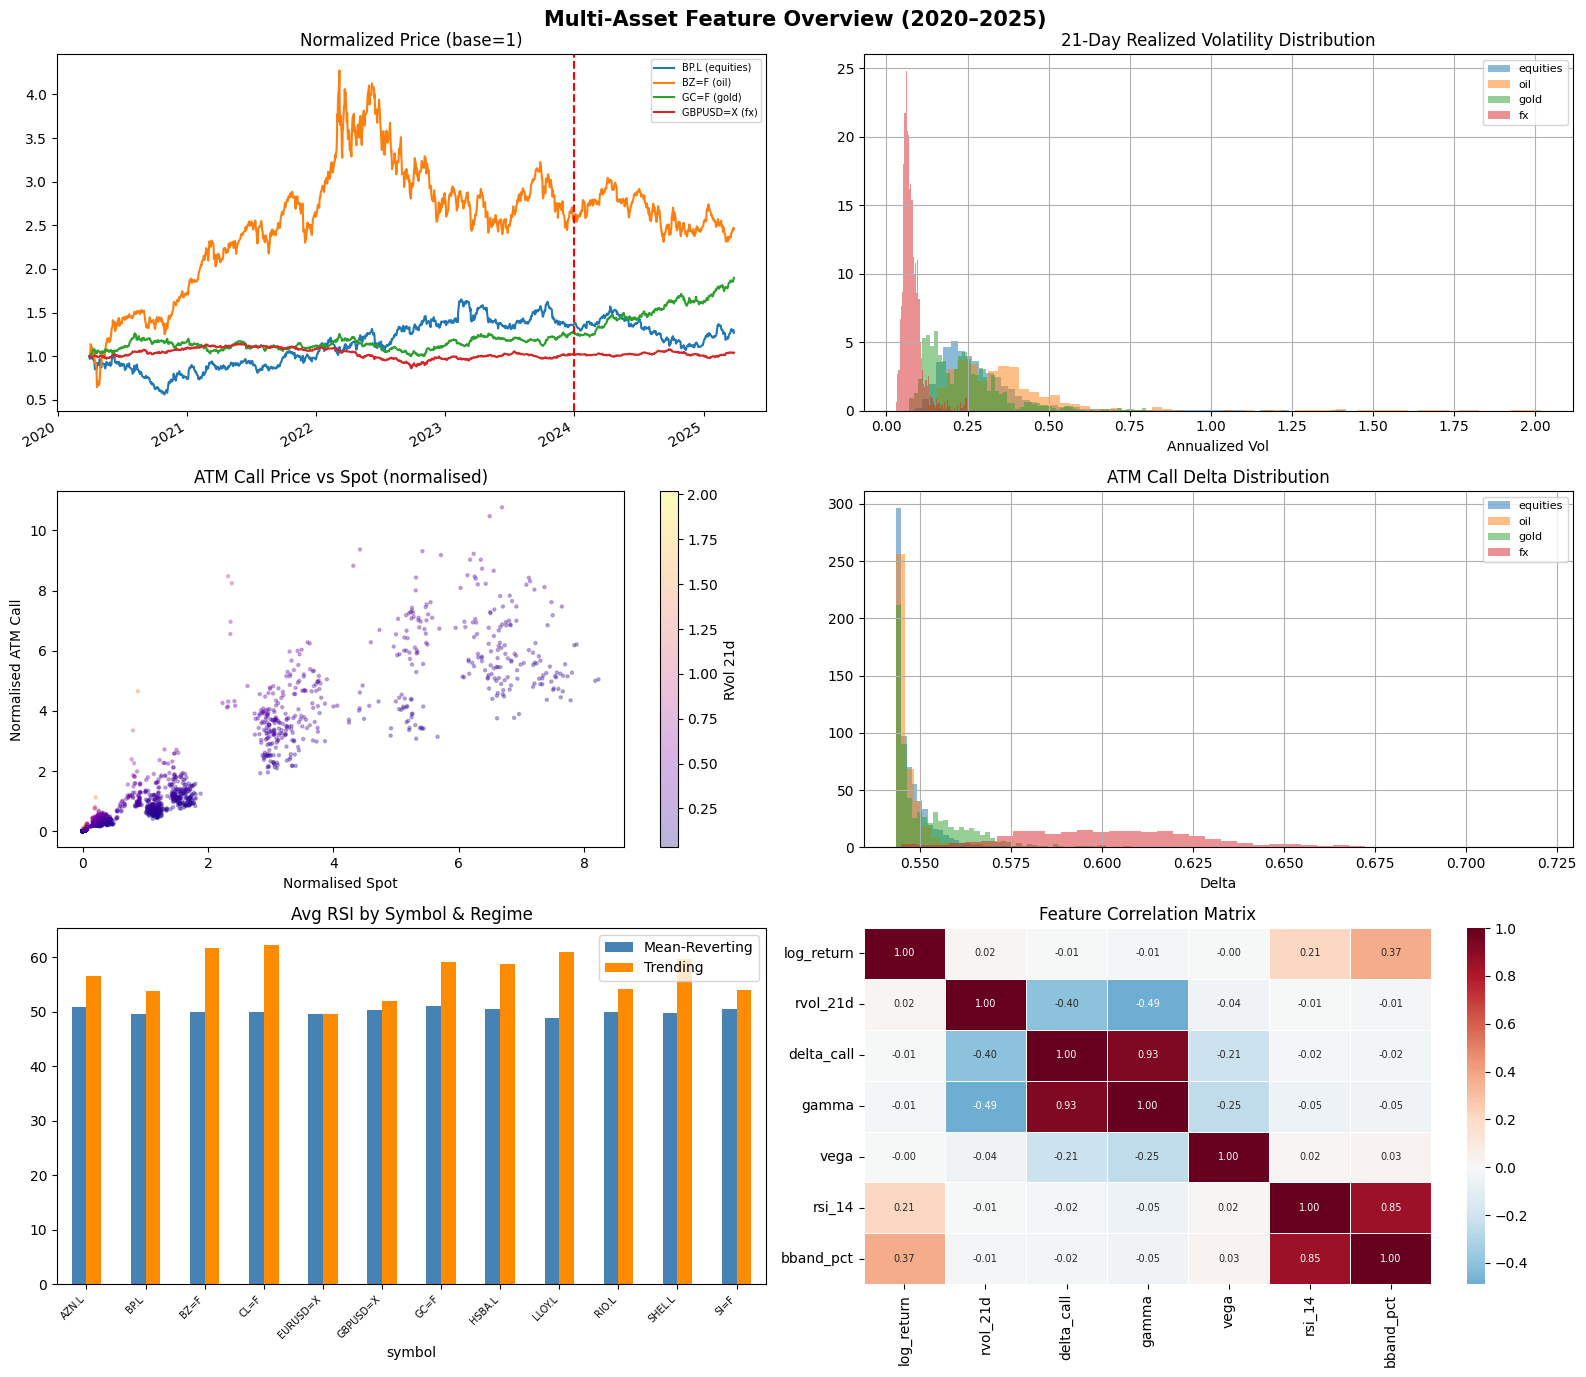

💾 Figure saved → c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks\results\01_data_overview.png


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Multi-Asset Feature Overview (2020–2025)", fontsize=15, fontweight="bold")

# 1. Normalized price history per asset class
ax = axes[0, 0]
for cls in all_features_clean["asset_class"].unique():
    sub = all_features_clean[all_features_clean["asset_class"] == cls].copy()
    # Take first symbol of each class for illustration
    sym0 = sub["symbol"].iloc[0]
    sub2 = sub[sub["symbol"] == sym0].set_index("date")["close"]
    (sub2 / sub2.iloc[0]).plot(ax=ax, label=f"{sym0} ({cls})")
ax.set_title("Normalized Price (base=1)")
ax.legend(fontsize=7)
ax.axvline(pd.Timestamp(VAL_START), color="red", linestyle="--", label="Train|Val split")
ax.set_xlabel("")

# 2. Realized vol distribution
ax = axes[0, 1]
for cls in all_features_clean["asset_class"].unique():
    sub = all_features_clean[all_features_clean["asset_class"] == cls]["rvol_21d"].dropna()
    sub.hist(ax=ax, bins=60, alpha=0.5, label=cls, density=True)
ax.set_title("21-Day Realized Volatility Distribution")
ax.set_xlabel("Annualized Vol")
ax.legend(fontsize=8)

# 3. ATM call price vs spot
ax = axes[1, 0]
sample = all_features_clean.sample(min(3000, len(all_features_clean)), random_state=42)
sc = ax.scatter(sample["close"] / sample["close"].mean(),  # normalize
                sample["atm_call_price"] / sample["atm_call_price"].mean(),
                c=sample["rvol_21d"], cmap="plasma", alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label="RVol 21d")
ax.set_title("ATM Call Price vs Spot (normalised)")
ax.set_xlabel("Normalised Spot")
ax.set_ylabel("Normalised ATM Call")

# 4. Delta distribution — calls
ax = axes[1, 1]
for cls in all_features_clean["asset_class"].unique():
    sub = all_features_clean[all_features_clean["asset_class"] == cls]["delta_call"].dropna()
    sub.hist(ax=ax, bins=40, alpha=0.5, label=cls, density=True)
ax.set_title("ATM Call Delta Distribution")
ax.set_xlabel("Delta")
ax.legend(fontsize=8)

# 5. RSI heatmap-ish by regime
ax = axes[2, 0]
pivot = all_features_clean.groupby(["symbol", "regime"])["rsi_14"].mean().unstack()
pivot.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Avg RSI by Symbol & Regime")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.legend(["Mean-Reverting", "Trending"])

# 6. Correlation heatmap of key features
ax = axes[2, 1]
corr_cols = ["log_return", "rvol_21d", "delta_call", "gamma", "vega", "rsi_14", "bband_pct"]
corr_cols = [c for c in corr_cols if c in all_features_clean.columns]
corr = all_features_clean[corr_cols].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix")

plt.tight_layout()
fig_path = os.path.join(PATHS["results"], "01_data_overview.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Figure saved → {fig_path}")

## 7. Data Quality Validation

In [10]:
print("=" * 60)
print(" DATA QUALITY REPORT")
print("=" * 60)

df = all_features_clean

# 1. NaN check
nan_pct = df[FEATURE_COLS].isna().mean() * 100
print("\n[1] NaN % in feature columns:")
bad = nan_pct[nan_pct > 1]
if len(bad) == 0:
    print("  ✅ All feature columns < 1% NaN")
else:
    print(bad.to_string())

# 2. Infinity check
inf_count = np.isinf(df[FEATURE_COLS].select_dtypes(include=np.number)).sum()
print(f"\n[2] Inf values: {inf_count.sum()} total")
if inf_count.sum() == 0:
    print("  ✅ No infinity values")

# 3. Delta sanity
delta_ok = df["delta_call"].between(0, 1).all()
print(f"\n[3] Call delta ∈ [0,1]: {'✅' if delta_ok else '❌'}")
delta_put_ok = df["delta_put"].between(-1, 0).all()
print(f"     Put delta ∈ [-1,0]: {'✅' if delta_put_ok else '❌'}")

# 4. Put-Call parity sanity (ATM: call - put ≈ S - Ke^-rT)
T_test = 30/252
K_test = df["close"].values
parity_lhs = df["atm_call_price"].values - df["atm_put_price"].values
parity_rhs = df["close"].values - K_test * np.exp(-R_FREE * T_test)
parity_err  = np.abs(parity_lhs - parity_rhs).mean()
print(f"\n[4] Put-Call Parity avg error: {parity_err:.6f}  {'✅' if parity_err < 0.01 else '⚠️'}")

# 5. Train/val leakage check
train_end_actual = df[df["split"]=="train"]["date"].max()
val_start_actual = df[df["split"]=="val"]["date"].min()
print(f"\n[5] Train ends: {train_end_actual.date()}")
print(f"     Val starts: {val_start_actual.date()}")
print(f"     No overlap: {'✅' if val_start_actual > train_end_actual else '❌ LEAK!'}")

# 6. Summary stats
print("\n[6] Per-asset row counts:")
print(df.groupby(["asset_class", "symbol"])[["date"]].count().rename(columns={"date":"rows"}))

print("\n" + "="*60)
print(" ✅ DATA READY FOR RL TRAINING")
print("="*60)

 DATA QUALITY REPORT

[1] NaN % in feature columns:
  ✅ All feature columns < 1% NaN

[2] Inf values: 0 total
  ✅ No infinity values

[3] Call delta ∈ [0,1]: ✅
     Put delta ∈ [-1,0]: ✅

[4] Put-Call Parity avg error: 0.999042  ⚠️

[5] Train ends: 2023-12-29
     Val starts: 2024-01-01
     No overlap: ✅

[6] Per-asset row counts:
                      rows
asset_class symbol        
equities    AZN.L     1261
            BP.L      1260
            HSBA.L    1261
            LLOY.L    1261
            RIO.L     1261
            SHEL.L    1261
fx          EURUSD=X  1304
            GBPUSD=X  1304
gold        GC=F      1255
            SI=F      1255
oil         BZ=F      1256
            CL=F      1253

 ✅ DATA READY FOR RL TRAINING


## 8. Summary — Files Produced

| File | Path | Description |
|------|------|-------------|
| `equities_raw.csv` | `data/raw/` | Raw OHLCV for 6 LSE equities |
| `oil_raw.csv` | `data/raw/` | Brent + WTI crude |
| `gold_raw.csv` | `data/raw/` | Gold + Silver futures |
| `fx_raw.csv` | `data/raw/` | GBP/USD, EUR/USD |
| `all_assets_raw.csv` | `data/raw/` | All tickers combined |
| `all_assets_features.csv` | `data/processed/` | ⭐ Main feature matrix (train+val, normalized) |
| `options_chains.csv` | `data/processed/` | Synthetic options across strikes & maturities |
| `scaler_meta.json` | `data/processed/` | Scaler params for inference |
| `{SYM}_features.csv` | `data/interim/per_asset/` | Per-ticker feature files |
| `01_data_overview.png` | `results/` | EDA plot |

---

**➡️ Next:** Open `02_RL_DL_Training.ipynb` to train the hedging agent.